# ROMS–COSiNE parameter analysis

This notebook summarizes optimization progress, compares selected runs, identifies parameters that concentrate among low-cost solutions, and uses nonlinear surrogate models to explore parameter importance and response shape.

Run the notebook from top to bottom after editing the **Configuration** cell. All analysis choices that are likely to change between archives are collected there. Lower values are assumed to be better for every target listed in `ANALYSIS_TARGETS`.

The analyses are diagnostic rather than causal. They describe the runs present in the archive; they do not establish that changing one parameter alone will produce the estimated response in a new ROMS–COSiNE run.

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RepeatedKFold, cross_validate

# Use consistent display defaults throughout the notebook.
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
pd.set_option("display.max_rows", 100)

## 1. Configuration

`ROMS_OPT_DIR` can be set in the environment to move the analysis without editing the notebook. `OBJECTIVE_VERSION=None` accepts the archive when it contains exactly one objective version; set a version explicitly when the CSV contains several.

Add or remove entries in `ANALYSIS_TARGETS` to analyze other lower-is-better objective columns. `FOCUS_PARAMETER=None` automatically selects the most important parameter for the primary target after permutation importance is calculated.

In [14]:
# Paths and archive selection
# Prefer an environment variable when present; otherwise use the original default location.
OPT_DIR = Path(os.environ.get("ROMS_OPT_DIR", Path.home() / "Desktop" / "Optimization"))
RUN_SUMMARY_FILE = OPT_DIR / "Model_Run_Summary_Bio.csv"
OBJECTIVE_VERSION = None  # None is safe only when the archive contains one version.

# Targets and run labels
ANALYSIS_TARGETS = ["Cost", "Bottom pH Objective"]
PRIMARY_TARGET = "Cost"  # Used to define best runs and parameter stability.
OPTIMIZER_RUN_PREFIX = "OPTUNA_"
LABEL_BELOW = {"Cost": 50}  # Use {} to disable point labels.

# Diagnostic settings
HIGHLIGHT_FRACTION = 0.10
ELITE_FRACTION = 0.20
MIN_PARAMETER_COVERAGE = 1.00  # Require a parameter value in every usable run.
TOP_IMPORTANCES = 15
TOP_CORRELATION_PARAMETERS = 10
STRONG_CORRELATION = 0.70
FOCUS_PARAMETER = "aksio4s2"  # None chooses the top-ranked parameter automatically.

# Reproducible surrogate-model settings
RANDOM_STATE = 42
N_TREES = 200
CV_SPLITS = 5
CV_REPEATS = 3
IMPORTANCE_CV_REPEATS = 2
PERMUTATION_REPEATS = 5

## 2. Load and audit the run archive

Objective columns are detected by the `" Objective"` suffix. Their corresponding signed nRMSE columns and run metadata are excluded from the parameter list. Parameters are then divided into varied and constant columns; only varied parameters can be evaluated for stability or importance.

In [15]:
if not RUN_SUMMARY_FILE.is_file():
    raise FileNotFoundError(
        f"Run summary not found: {RUN_SUMMARY_FILE}\n"
        "Set ROMS_OPT_DIR or update OPT_DIR in the configuration cell."
    )

# Keep the full archive in one canonical dataframe; later sections create local subsets.
DF_runs = pd.read_csv(RUN_SUMMARY_FILE)

# Fail early with a useful message instead of failing deep inside a later plot.
required_columns = {"Run Name", "Trial Number", "Cost", "Objective Version", *ANALYSIS_TARGETS}
missing_required = sorted(required_columns.difference(DF_runs.columns))
if missing_required:
    raise ValueError(f"Required columns not found: {missing_required}")

# Results from different objective definitions are not directly comparable.
available_versions = DF_runs["Objective Version"].dropna().unique().tolist()
if OBJECTIVE_VERSION is None:
    if len(available_versions) != 1:
        raise ValueError(
            f"Found objective versions {available_versions}. Set OBJECTIVE_VERSION explicitly."
        )
    selected_objective_version = available_versions[0]
else:
    selected_objective_version = OBJECTIVE_VERSION
    # Make an explicit copy so later assignments cannot modify a dataframe view.
    DF_runs = DF_runs.loc[
        DF_runs["Objective Version"].eq(selected_objective_version)
    ].copy()
    if DF_runs.empty:
        raise ValueError(f"No runs found for objective version {selected_objective_version!r}.")

print(f"Archive: {RUN_SUMMARY_FILE}")
print(f"Objective version: {selected_objective_version}")
print(f"Runs: {len(DF_runs):,}; columns: {len(DF_runs.columns):,}")

Archive: /Users/akbaskind/Desktop/Optimization/Model_Run_Summary_Bio.csv
Objective version: cost_v3_bio_no_temp_salt
Runs: 107; columns: 130


In [16]:
# Objective columns follow a naming convention, so discover them instead of listing them manually.
objective_cols = [column for column in DF_runs.columns if column.endswith(" Objective")]
rmse_cols = [column.removesuffix(" Objective") for column in objective_cols]

# These numeric outputs and identifiers must not be mistaken for tunable parameters.
metadata_cols = {
    "Run Name", "Cost File", "Station File", "Cost", "Cost Status",
    "Parameter Status", "Objective Version", "Trial Number",
    *rmse_cols, *objective_cols,
}
parameter_cols = [
    column for column in DF_runs.select_dtypes(include="number").columns
    if column not in metadata_cols
]
# A constant parameter cannot explain differences among runs, so set it aside.
parameter_unique_counts = DF_runs[parameter_cols].nunique(dropna=True).sort_values()
varied_parameter_cols = parameter_unique_counts[parameter_unique_counts > 1].index.tolist()
constant_parameter_cols = parameter_unique_counts[parameter_unique_counts <= 1].index.tolist()

archive_audit = pd.DataFrame({
    "Category": ["Objective columns", "Signed nRMSE columns", "All parameters", "Varied parameters", "Constant/all-missing parameters"],
    "Count": [len(objective_cols), len(rmse_cols), len(parameter_cols), len(varied_parameter_cols), len(constant_parameter_cols)],
})
display(archive_audit)
print("Varied parameters:", varied_parameter_cols)

,Category,Count
0,Objective columns,12
1,Signed nRMSE columns,12
2,All parameters,95
3,Varied parameters,63
4,Constant/all-missing parameters,32


Varied parameters: ['bUmaxSi_nspc0', 'bUmaxSi_nspc1', 'bpsi_n', 'bao2', 'o2nh', 'aksio4s2', 'c2n', 'bfp_nspc2', 'bfn_nspc0', 'bfp_nspc0', 'bfn_nspc1', 'bfn_nspc2', 'bfc_nspc0', 'bfc_nspc2', 'bfp_nspc1', 'bfs_nspc2', 'akpo4s1', 'pis2', 'pis1', 'cacodr', 'omega_thresh', 'wsPCa', 'ro5', 'o2no', 'ro6', 'aknh4s1', 'bgamma0', 'cacopf', 'Chl2cs1_m', 'bgamma5s', 'akno3s1', 'wsp', 'nl_tnu2_tracer9', 'bfs_nspc0', 'bfs_nspc1', 'bpsi_p', 'wsdsi', 'Chl2cs2_m', 'akno3s2', 'bgamma3', 'rrb1', 'rrb2', 'rrg2', 'rrg1', 'gmaxs1', 'amaxs1', 'bgamma4', 'gmaxs2', 'amaxs2', 'akz1', 'akz2', 'reg2', 'reg1', 'bgamma6', 'beta1', 'beta2', 'bUmax_nspc0', 'bnit', 'wsd', 'bUmax_nspc1', 'bdenit', 'bgamma7', 'bgamma5']


## 3. Optimization progress

Each dot is one completed run. Colors distinguish historical runs from optimizer-generated runs, green rings mark the best fraction configured by `HIGHLIGHT_FRACTION`, and the black staircase is the best value available up to each trial.

Interpret a descending staircase as discovery of improved solutions. A long flat section means no new best run was found over that interval; it does **not** by itself prove convergence. The spread of dots shows the breadth of continued exploration. For objective components, plot the `... Objective` column—not the signed nRMSE—when “lower is better” is required.

In [17]:
def prepare_progress(df, metric):
    # Return trial-ordered, complete observations for one lower-is-better metric.
    # Remove incomplete observations before sorting; cummin depends on trial order.
    progress = (
        df.dropna(subset=["Trial Number", metric])
        .sort_values("Trial Number")
        .copy()
    )
    # cummin creates the descending staircase of the best value available at each trial.
    progress["Best So Far"] = progress[metric].cummin()
    # Positive values mark trials that improved on the previous running best.
    progress["Improvement"] = progress["Best So Far"].shift(1) - progress["Best So Far"]
    # Infer run origin from the configured naming convention.
    progress["Run Type"] = np.where(
        progress["Run Name"].astype(str).str.startswith(OPTIMIZER_RUN_PREFIX),
        "Optimizer", "Historical",
    )
    return progress


def plot_optimization_progress(progress, metric, highlight_fraction=0.10, label_below=None):
    # Plot observed values and the running minimum for one metric.
    if progress.empty:
        raise ValueError(f"No complete trials are available for {metric!r}.")

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = {"Historical": "tab:blue", "Optimizer": "tab:orange"}
    for run_type, group in progress.groupby("Run Type", sort=False):
        ax.scatter(group["Trial Number"], group[metric], color=colors[run_type],
                   alpha=0.8, label=f"{run_type} run", zorder=3)

    # For a lower-is-better metric, the chosen lower quantile contains the highlighted runs.
    threshold = progress[metric].quantile(highlight_fraction)
    highlighted = progress[metric].le(threshold)
    ax.scatter(progress.loc[highlighted, "Trial Number"], progress.loc[highlighted, metric],
               facecolors="none", edgecolors="limegreen", s=120, linewidths=2,
               label=f"Lowest {highlight_fraction:.0%}", zorder=4)
    ax.plot(progress["Trial Number"], progress["Best So Far"], color="black",
            linewidth=2, label="Best so far", zorder=2)

    # Point labels are optional because they become cluttered for less selective thresholds.
    if label_below is not None:
        for _, row in progress.loc[progress[metric] < label_below].iterrows():
            ax.annotate(row["Run Name"], (row["Trial Number"], row[metric]),
                        xytext=(5, 5), textcoords="offset points", fontsize=8)
        ax.axhline(label_below, color="gray", linestyle="--", linewidth=1,
                   alpha=0.7, label=f"Label threshold = {label_below:g}")

    ax.set(xlabel="Trial number", ylabel=metric, title=f"Optimization progress: {metric}")
    ax.grid(linestyle="--", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fig, threshold

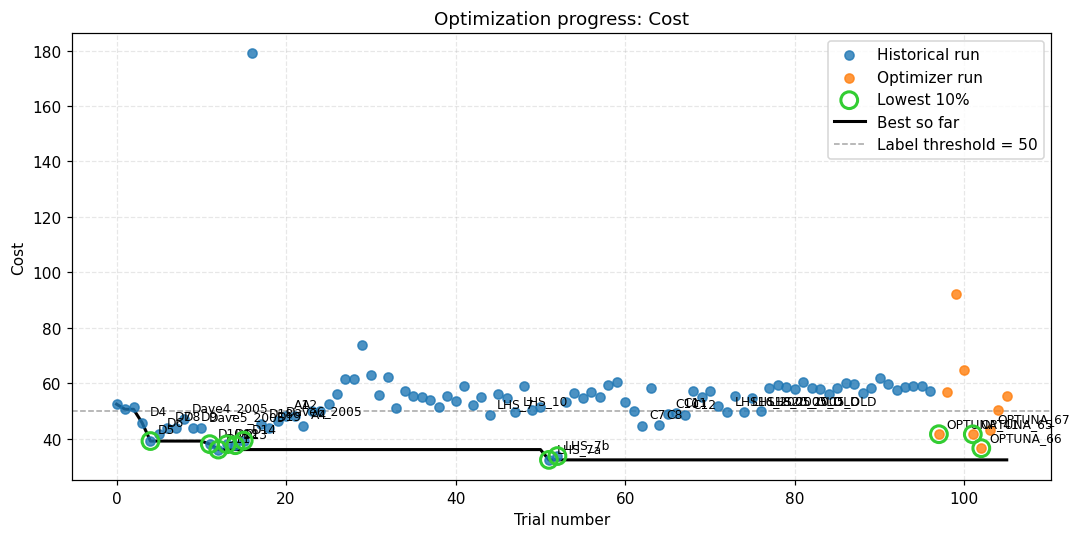

Cost: 106 completed trials; lowest 10% threshold = 41.6594


,Trial Number,Run Name,Cost,Best So Far,Improvement
0,0.0,Dave1_2005,52.385628,52.385628,NaN
1,1.0,Dave2_2005,50.539094,50.539094,1.846534
2,3.0,D4,45.757200,45.757200,4.781895
3,4.0,D5,39.075795,39.075795,6.681405
4,11.0,D10-2,37.962919,37.962919,1.112876
5,12.0,D11,36.003680,36.003680,1.959239
6,51.0,LHS_7a,32.284426,32.284426,3.719254


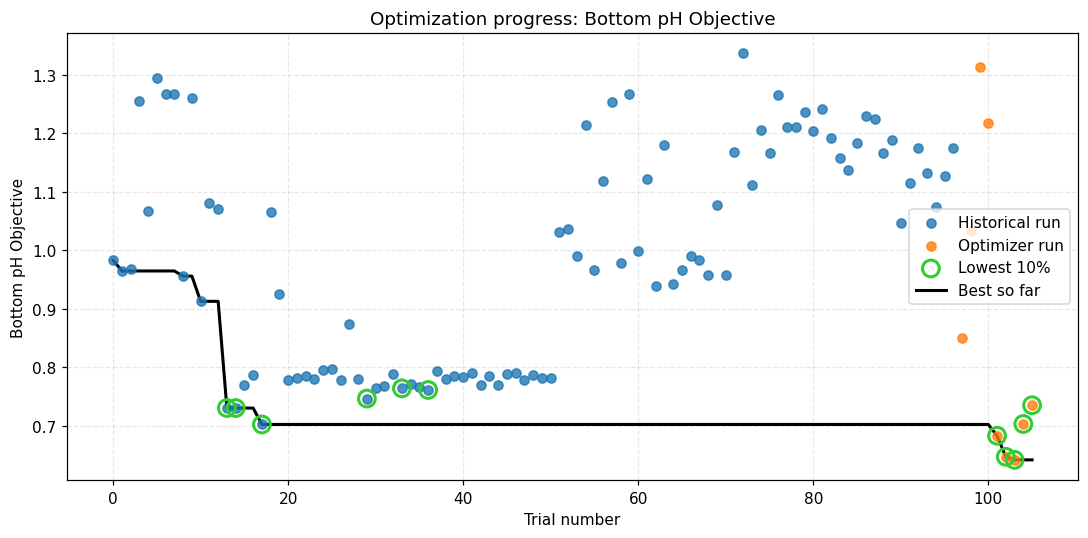

Bottom pH Objective: 106 completed trials; lowest 10% threshold = 0.763722


,Trial Number,Run Name,Bottom pH Objective,Best So Far,Improvement
0,0.0,Dave1_2005,0.982833,0.982833,NaN
1,1.0,Dave2_2005,0.964375,0.964375,0.018458
2,8.0,Dave4_2005,0.955550,0.955550,0.008825
3,10.0,Dave5_2005,0.912452,0.912452,0.043098
4,13.0,D12,0.729938,0.729938,0.182515
5,14.0,D13,0.729879,0.729879,0.000059
6,17.0,D18,0.701831,0.701831,0.028048
7,101.0,OPTUNA_65,0.682559,0.682559,0.019271
8,102.0,OPTUNA_66,0.646529,0.646529,0.036031
9,103.0,OPTUNA_67,0.641253,0.641253,0.005276


In [18]:
# Store each target separately so one progress calculation cannot overwrite another.
progress_by_target = {}
improvement_tables = {}

for target in ANALYSIS_TARGETS:
    progress = prepare_progress(DF_runs, target)
    progress_by_target[target] = progress
    _, threshold = plot_optimization_progress(
        progress, target,
        highlight_fraction=HIGHLIGHT_FRACTION,
        label_below=LABEL_BELOW.get(target),
    )
    # Keep only record-setting trials; include the first trial as the initial benchmark.
    improvement_mask = progress["Improvement"].gt(0)
    if not progress.empty:
        improvement_mask.iloc[0] = True
    improvement_tables[target] = progress.loc[
        improvement_mask,
        ["Trial Number", "Run Name", target, "Best So Far", "Improvement"],
    ].reset_index(drop=True)
    print(f"{target}: {len(progress)} completed trials; lowest {HIGHLIGHT_FRACTION:.0%} threshold = {threshold:.6g}")
    display(improvement_tables[target])

## 4. Compare a historical benchmark with an optimizer run

The historical benchmark is the historical run with the lowest `PRIMARY_TARGET`; the optimizer comparator is the latest completed optimizer run. “Latest” is useful for checking the current state of a workflow but is not necessarily the best optimizer run. The parameter table reports signed changes (`latest − historical`) and percent changes relative to the magnitude of the historical value.

In [19]:
# Build this comparison directly from PRIMARY_TARGET, independent of earlier loop state.
comparison_runs = prepare_progress(DF_runs, PRIMARY_TARGET)
historical_runs = comparison_runs.loc[comparison_runs["Run Type"].eq("Historical")]
optimizer_runs = comparison_runs.loc[comparison_runs["Run Type"].eq("Optimizer")]
if historical_runs.empty or optimizer_runs.empty:
    raise ValueError("Both historical and optimizer runs are required for this comparison.")

# idxmin selects the best historical row; iloc[-1] selects the chronologically latest optimizer row.
best_historical = historical_runs.loc[historical_runs[PRIMARY_TARGET].idxmin()]
latest_optimizer = optimizer_runs.sort_values("Trial Number").iloc[-1]

run_comparison = pd.DataFrame([
    {"Role": "Best historical", "Run Name": best_historical["Run Name"],
     "Trial Number": best_historical["Trial Number"], PRIMARY_TARGET: best_historical[PRIMARY_TARGET]},
    {"Role": "Latest optimizer", "Run Name": latest_optimizer["Run Name"],
     "Trial Number": latest_optimizer["Trial Number"], PRIMARY_TARGET: latest_optimizer[PRIMARY_TARGET]},
])
display(run_comparison)

,Role,Run Name,Trial Number,Cost
0,Best historical,LHS_7a,51.0,32.284426
1,Latest optimizer,OPTUNA_75,105.0,55.459880


In [20]:
# Compare only parameters that varied somewhere in the archive.
comparison_rows = []
for parameter in varied_parameter_cols:
    # Coerce unexpected text to NaN so it can be skipped safely.
    historical_value = pd.to_numeric(pd.Series([best_historical[parameter]]), errors="coerce").iloc[0]
    optimizer_value = pd.to_numeric(pd.Series([latest_optimizer[parameter]]), errors="coerce").iloc[0]
    if pd.isna(historical_value) or pd.isna(optimizer_value):
        continue
    # Treat tiny floating-point differences as equal.
    if np.isclose(historical_value, optimizer_value, rtol=1e-9, atol=1e-12):
        continue
    difference = optimizer_value - historical_value
    # Absolute denominator preserves the sign of the change when the old value is negative.
    percent_change = 100 * difference / abs(historical_value) if historical_value != 0 else np.nan
    comparison_rows.append({
        "Parameter": parameter, "Best Historical": historical_value,
        "Latest Optimizer": optimizer_value, "Difference": difference,
        "Percent Change": percent_change,
    })

DF_parameter_comparison = pd.DataFrame(comparison_rows)
if not DF_parameter_comparison.empty:
    DF_parameter_comparison = DF_parameter_comparison.sort_values(
        "Percent Change", key=lambda values: values.abs(), ascending=False, na_position="last"
    ).reset_index(drop=True)
display(DF_parameter_comparison)

,Parameter,Best Historical,Latest Optimizer,Difference,Percent Change
0,akno3s2,1.000000,3.000000,2.000000,200.000000
1,Chl2cs2_m,0.026750,0.060000,0.033250,124.299065
2,aksio4s2,1.000000,2.000000,1.000000,100.000000
3,bfs_nspc1,0.350000,0.650000,0.300000,85.714286
4,bUmax_nspc1,0.020000,0.003453,-0.016547,-82.733194
5,akz2,2.000000,0.500000,-1.500000,-75.000000
6,pis2,5.590000,1.590000,-4.000000,-71.556351
7,bgamma4,0.250000,0.083550,-0.166450,-66.579804
8,bdenit,25.869046,9.381129,-16.487917,-63.736085
9,wsdsi,5.000000,2.000000,-3.000000,-60.000000


## 5. Parameter stability among elite runs

For each varied parameter, the gray line represents its full tested range and the green line represents the range occupied by the best `ELITE_FRACTION` of runs according to `PRIMARY_TARGET`. Values are normalized separately for each parameter, so horizontal positions from 0 to 1 mean “minimum to maximum tested,” not common physical units.

A short green segment indicates that good runs cluster in a narrow part of the tested range and may identify a constrained parameter. A segment pressed against 0 or 1 suggests the optimum may lie near or beyond a tested boundary. Treat `u=1` (one unique elite value) cautiously: it can reflect sparse sampling rather than genuine stability. Wide segments can indicate weak constraint, interactions, multiple good regions, or insufficient sampling.

In [9]:
def calculate_parameter_stability(df, parameters, target, elite_fraction=0.20):
    # Define elite runs from all rows with a usable lower-is-better target value.
    analysis = df.dropna(subset=[target]).copy()
    threshold = analysis[target].quantile(elite_fraction)
    elite = analysis.loc[analysis[target].le(threshold)]
    rows = []
    for parameter in parameters:
        all_values = pd.to_numeric(analysis[parameter], errors="coerce").dropna()
        elite_values = pd.to_numeric(elite[parameter], errors="coerce").dropna()
        if all_values.empty or elite_values.empty:
            continue
        # Compare the elite span with the total span explored for this parameter.
        full_range = all_values.max() - all_values.min()
        elite_range = elite_values.max() - elite_values.min()
        rows.append({
            "Parameter": parameter, "All Runs Min": all_values.min(), "All Runs Max": all_values.max(),
            "All Runs Range": full_range, "Elite Min": elite_values.min(), "Elite Max": elite_values.max(),
            # A small range fraction means elite runs occupy a narrow part of the tested range.
            "Elite Range": elite_range, "Range Fraction": elite_range / full_range if full_range > 0 else np.nan,
            "All Runs Median": all_values.median(), "Elite Median": elite_values.median(),
            "All Runs Unique": all_values.nunique(), "Elite Unique": elite_values.nunique(),
            "Elite Count": len(elite_values),
        })
    result = pd.DataFrame(rows)
    if not result.empty:
        # Put the most tightly clustered parameters first in the table.
        result = result.sort_values(["Range Fraction", "Elite Unique"], na_position="last").reset_index(drop=True)
    return result, threshold


DF_parameter_stability, elite_threshold = calculate_parameter_stability(
    DF_runs, varied_parameter_cols, PRIMARY_TARGET, ELITE_FRACTION
)
print(f"Elite threshold for {PRIMARY_TARGET}: {elite_threshold:.6g}")
display(DF_parameter_stability)

Elite threshold for Cost: 45.1974


,Parameter,All Runs Min,All Runs Max,All Runs Range,Elite Min,Elite Max,Elite Range,Range Fraction,All Runs Median,Elite Median,All Runs Unique,Elite Unique,Elite Count
0,bUmaxSi_nspc0,6.318713e-310,0.100000,0.100000,0.100000,0.100000,0.000000,0.000000,0.100000,0.100000,2,1,22
1,bUmaxSi_nspc1,6.318713e-310,0.020000,0.020000,0.020000,0.020000,0.000000,0.000000,0.020000,0.020000,2,1,22
2,bpsi_n,5.000000e-01,2.000000,1.500000,2.000000,2.000000,0.000000,0.000000,2.000000,2.000000,2,1,22
3,o2nh,6.625000e+00,9.210000,2.585000,9.210000,9.210000,0.000000,0.000000,9.210000,9.210000,2,1,22
4,c2n,6.625000e+00,8.460000,1.835000,8.460000,8.460000,0.000000,0.000000,8.460000,8.460000,2,1,22
5,bfp_nspc2,1.000000e-01,0.500000,0.400000,0.100000,0.100000,0.000000,0.000000,0.100000,0.100000,2,1,22
6,bfn_nspc0,1.500000e-01,0.250000,0.100000,0.250000,0.250000,0.000000,0.000000,0.250000,0.250000,2,1,22
7,bfp_nspc0,1.500000e-01,0.250000,0.100000,0.250000,0.250000,0.000000,0.000000,0.250000,0.250000,2,1,22
8,bfn_nspc1,5.000000e-01,0.650000,0.150000,0.650000,0.650000,0.000000,0.000000,0.650000,0.650000,2,1,22
9,bfn_nspc2,1.000000e-01,0.400000,0.300000,0.100000,0.100000,0.000000,0.000000,0.100000,0.100000,2,1,22


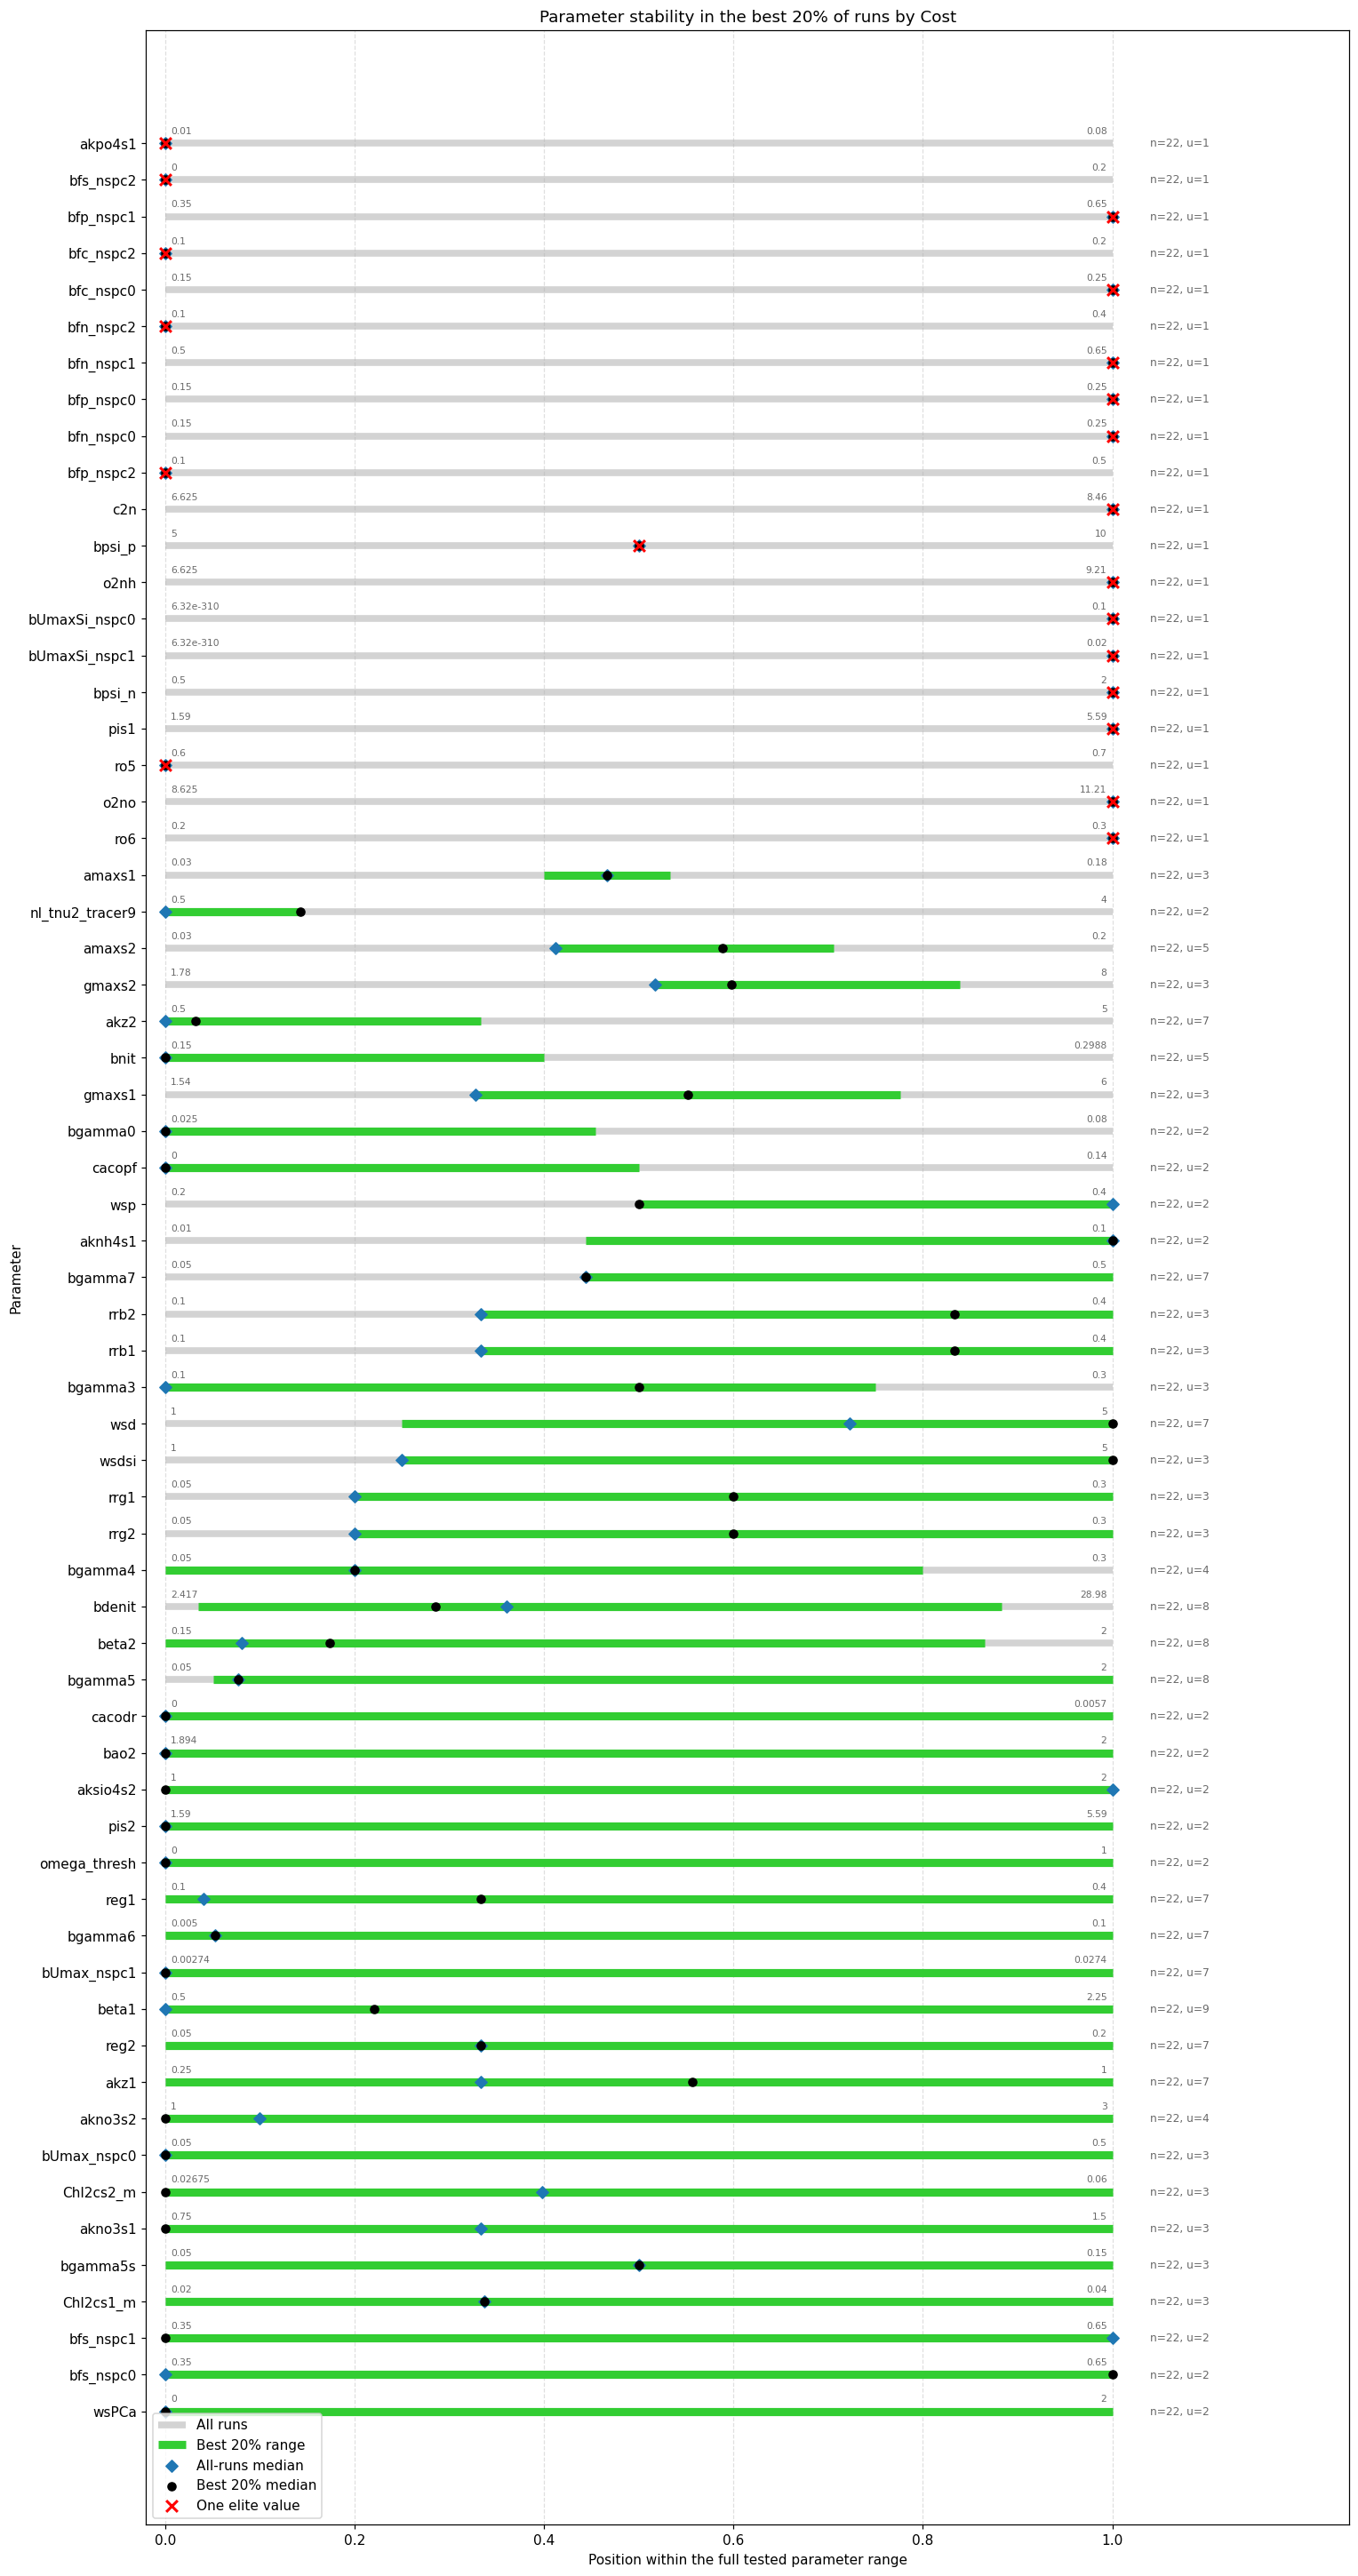

In [21]:
# Keep annotations readable across parameters with very different numerical scales.
def format_parameter_value(value):
    if pd.isna(value): return "NA"
    value = float(value)
    if value == 0: return "0"
    return f"{value:.2e}" if abs(value) < 0.001 or abs(value) >= 1000 else f"{value:.4g}"


def plot_parameter_stability(stability, target, elite_fraction):
    # Zero-range parameters cannot be normalized and contain no stability information.
    plot_data = stability.loc[stability["All Runs Range"] > 0].copy()
    # Convert each parameter to its own 0–1 tested range so they share one x-axis.
    for output, source in {
        "Normalized Low": "Elite Min", "Normalized High": "Elite Max",
        "Normalized Elite Median": "Elite Median", "Normalized All Median": "All Runs Median",
    }.items():
        plot_data[output] = (plot_data[source] - plot_data["All Runs Min"]) / plot_data["All Runs Range"]
    # Plot broad elite ranges first so the narrowest, most constrained ranges appear at the top.
    plot_data = plot_data.sort_values("Range Fraction", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(14, max(5, 0.42 * len(plot_data))))
    y = np.arange(len(plot_data))
    # Gray = full tested range; green = range occupied by elite runs.
    ax.hlines(y, 0, 1, color="lightgray", linewidth=5, label="All runs", zorder=1)
    ax.hlines(y, plot_data["Normalized Low"], plot_data["Normalized High"],
              color="limegreen", linewidth=6, label=f"Best {elite_fraction:.0%} range", zorder=2)
    ax.scatter(plot_data["Normalized All Median"], y, color="tab:blue", marker="D", s=38,
               label="All-runs median", zorder=3)
    ax.scatter(plot_data["Normalized Elite Median"], y, color="black", s=35,
               label=f"Best {elite_fraction:.0%} median", zorder=4)

    # Add true (unnormalized) endpoints and elite sampling counts beside each row.
    for position, (_, row) in enumerate(plot_data.iterrows()):
        ax.annotate(format_parameter_value(row["All Runs Min"]), (0, position), xytext=(4, 7),
                    textcoords="offset points", ha="left", fontsize=7, color="dimgray")
        ax.annotate(format_parameter_value(row["All Runs Max"]), (1, position), xytext=(-4, 7),
                    textcoords="offset points", ha="right", fontsize=7, color="dimgray")
        ax.text(1.04, position, f'n={int(row["Elite Count"])}, u={int(row["Elite Unique"])}',
                va="center", fontsize=8, color="dimgray")
    # Flag apparent stability based on only one sampled elite value.
    limited = plot_data["Elite Unique"].le(1).to_numpy()
    ax.scatter(plot_data.loc[limited, "Normalized Elite Median"], y[limited], marker="x",
               color="red", s=70, linewidths=2, label="One elite value", zorder=5)
    ax.set_yticks(y, plot_data["Parameter"])
    ax.set_xlim(-0.02, 1.25)
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set(xlabel="Position within the full tested parameter range", ylabel="Parameter",
           title=f"Parameter stability in the best {elite_fraction:.0%} of runs by {target}")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fig


stability_figure = plot_parameter_stability(DF_parameter_stability, PRIMARY_TARGET, ELITE_FRACTION)

## 6. Nonlinear parameter importance

The models below are statistical surrogates for the run archive. The audit first checks coverage, then repeated cross-validation tests whether nonlinear models predict held-out runs better than a mean-only baseline.

Read model validation before importance: positive held-out $R^2$ and lower MAE than the baseline support using the surrogate diagnostically. A large train/test gap indicates overfitting. If held-out performance is poor, rankings and response curves should not be interpreted.

Permutation importance is the increase in held-out MAE after shuffling one parameter. Large positive values mean predictions depended on that parameter. Error bars show variability across folds and permutations. Near-zero or negative values indicate weak or unstable predictive contribution—not proof that a parameter is physically irrelevant. Correlated parameters can share or mask importance.

In [11]:
# Audit missingness separately for each target because their usable run sets may differ.
audit_rows = []
for target in ANALYSIS_TARGETS:
    target_data = DF_runs.loc[pd.to_numeric(DF_runs[target], errors="coerce").notna()]
    for parameter in varied_parameter_cols:
        values = pd.to_numeric(target_data[parameter], errors="coerce")
        audit_rows.append({
            "Target": target, "Parameter": parameter, "Target Runs": len(target_data),
            "Available Values": values.notna().sum(), "Missing Values": values.isna().sum(),
            "Coverage": values.notna().mean(), "Unique Values": values.nunique(),
            "Minimum": values.min(), "Maximum": values.max(),
        })
DF_importance_audit = pd.DataFrame(audit_rows)

# Build a target-specific feature list using the configured coverage threshold.
importance_parameter_cols = {}
for target in ANALYSIS_TARGETS:
    target_audit = DF_importance_audit.loc[DF_importance_audit["Target"].eq(target)]
    selected = target_audit.loc[
        # A feature must be sufficiently complete and must vary among runs.
        target_audit["Coverage"].ge(MIN_PARAMETER_COVERAGE) & target_audit["Unique Values"].ge(2),
        "Parameter",
    ].tolist()
    if not selected:
        raise ValueError(f"No parameters meet the coverage criterion for {target!r}.")
    importance_parameter_cols[target] = selected

coverage_summary = pd.DataFrame([
    {"Target": target, "Target Runs": int(group["Target Runs"].iloc[0]),
     "Eligible Parameters": len(importance_parameter_cols[target]),
     "Minimum Coverage": MIN_PARAMETER_COVERAGE}
    for target, group in DF_importance_audit.groupby("Target", sort=False)
])
display(coverage_summary)

,Target,Target Runs,Eligible Parameters,Minimum Coverage
0,Cost,107,63,1.0
1,Bottom pH Objective,107,63,1.0


In [12]:
# The mean-only model provides a minimum benchmark for the nonlinear models.
models = {
    "Mean baseline": DummyRegressor(strategy="mean"),
    "Random Forest": RandomForestRegressor(
        n_estimators=N_TREES, max_features=0.7, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=N_TREES, max_features=0.7, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
}
# Repeated folds reduce dependence on one lucky train/test split.
cv = RepeatedKFold(n_splits=CV_SPLITS, n_repeats=CV_REPEATS, random_state=RANDOM_STATE)
performance_rows = []

for target in ANALYSIS_TARGETS:
    parameters = importance_parameter_cols[target]
    # Use complete cases so every compared model sees exactly the same runs and features.
    model_data = DF_runs[parameters + [target]].apply(pd.to_numeric, errors="coerce").dropna()
    X, y = model_data[parameters], model_data[target]
    for model_name, model in models.items():
        # Score held-out prediction and retain train R2 to diagnose overfitting.
        scores = cross_validate(
            model, X, y, cv=cv,
            scoring={"r2": "r2", "mae": "neg_mean_absolute_error"},
            return_train_score=True, n_jobs=-1,
        )
        performance_rows.append({
            "Target": target, "Model": model_name, "Runs": len(model_data), "Parameters": len(parameters),
            "Mean Test R2": scores["test_r2"].mean(), "SD Test R2": scores["test_r2"].std(),
            # sklearn negates MAE for scoring, so reverse its sign for readable output.
            "Mean Test MAE": -scores["test_mae"].mean(), "SD Test MAE": scores["test_mae"].std(),
            "Mean Train R2": scores["train_r2"].mean(),
        })

DF_model_performance = pd.DataFrame(performance_rows).sort_values(
    ["Target", "Mean Test R2"], ascending=[True, False]
).reset_index(drop=True)
display(DF_model_performance)

,Target,Model,Runs,Parameters,Mean Test R2,SD Test R2,Mean Test MAE,SD Test MAE,Mean Train R2
0,Bottom pH Objective,Extra Trees,107,63,0.687187,0.174475,0.065772,0.015941,0.936785
1,Bottom pH Objective,Random Forest,107,63,0.662618,0.192058,0.069304,0.014917,0.905761
2,Bottom pH Objective,Mean baseline,107,63,-0.098742,0.092603,0.175926,0.019342,0.000000
3,Cost,Mean baseline,107,63,-0.104577,0.118545,7.543601,2.380032,0.000000
4,Cost,Random Forest,107,63,-0.327837,0.842204,6.750868,3.200147,0.500636
5,Cost,Extra Trees,107,63,-0.590305,0.791074,6.860664,2.642132,0.654044


In [13]:
# Start from the validated model settings, but fit a fresh model in every fold.
importance_model = clone(models["Random Forest"])
importance_cv = RepeatedKFold(
    n_splits=CV_SPLITS, n_repeats=IMPORTANCE_CV_REPEATS, random_state=RANDOM_STATE
)
permutation_rows = []

for target in ANALYSIS_TARGETS:
    parameters = importance_parameter_cols[target]
    model_data = DF_runs[parameters + [target]].apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
    X, y = model_data[parameters], model_data[target]
    # Importance is measured only on held-out rows from each split.
    for split_number, (train_index, test_index) in enumerate(importance_cv.split(X), start=1):
        model = clone(importance_model).fit(X.iloc[train_index], y.iloc[train_index])
        # Shuffle one parameter at a time; lost predictive accuracy is its importance.
        result = permutation_importance(
            model, X.iloc[test_index], y.iloc[test_index], scoring="neg_mean_absolute_error",
            n_repeats=PERMUTATION_REPEATS, random_state=RANDOM_STATE + split_number, n_jobs=1,
        )
        # Retain every repeat instead of only its mean so uncertainty can be summarized later.
        for parameter_index, parameter in enumerate(parameters):
            for value in result.importances[parameter_index]:
                permutation_rows.append({
                    "Target": target, "Split": split_number,
                    "Parameter": parameter, "Importance": value,
                })

DF_permutation_raw = pd.DataFrame(permutation_rows)
# Pool all folds and permutation repeats into one summary row per target and parameter.
DF_permutation_importance = (
    DF_permutation_raw.groupby(["Target", "Parameter"], as_index=False)
    .agg(Mean_Importance=("Importance", "mean"), Median_Importance=("Importance", "median"),
         SD_Importance=("Importance", "std"),
         # Fraction positive is a simple measure of directional consistency.
         Positive_Fraction=("Importance", lambda values: values.gt(0).mean()))
)
# Rank within each target because MAE units differ between targets.
DF_permutation_importance["Rank"] = DF_permutation_importance.groupby("Target")["Mean_Importance"].rank(
    method="min", ascending=False
)
display(DF_permutation_importance.sort_values(["Target", "Rank"]).reset_index(drop=True))

,Target,Parameter,Mean_Importance,Median_Importance,SD_Importance,Positive_Fraction,Rank
0,Bottom pH Objective,beta2,0.033643,0.031312,0.018342,0.96,1.0
1,Bottom pH Objective,beta1,0.024015,0.020382,0.015752,0.98,2.0
2,Bottom pH Objective,bUmax_nspc1,0.019012,0.019657,0.009125,1.00,3.0
3,Bottom pH Objective,akz1,0.007718,0.007407,0.006544,0.90,4.0
4,Bottom pH Objective,bgamma6,0.004548,0.003305,0.007135,0.78,5.0
...,...,...,...,...,...,...,...
121,Cost,rrg2,-0.017192,0.001217,0.089014,0.50,59.0
122,Cost,akz2,-0.030161,-0.030208,0.056407,0.38,60.0
123,Cost,beta2,-0.037295,-0.029385,0.109458,0.40,61.0
124,Cost,bdenit,-0.087962,-0.088634,0.252303,0.34,62.0


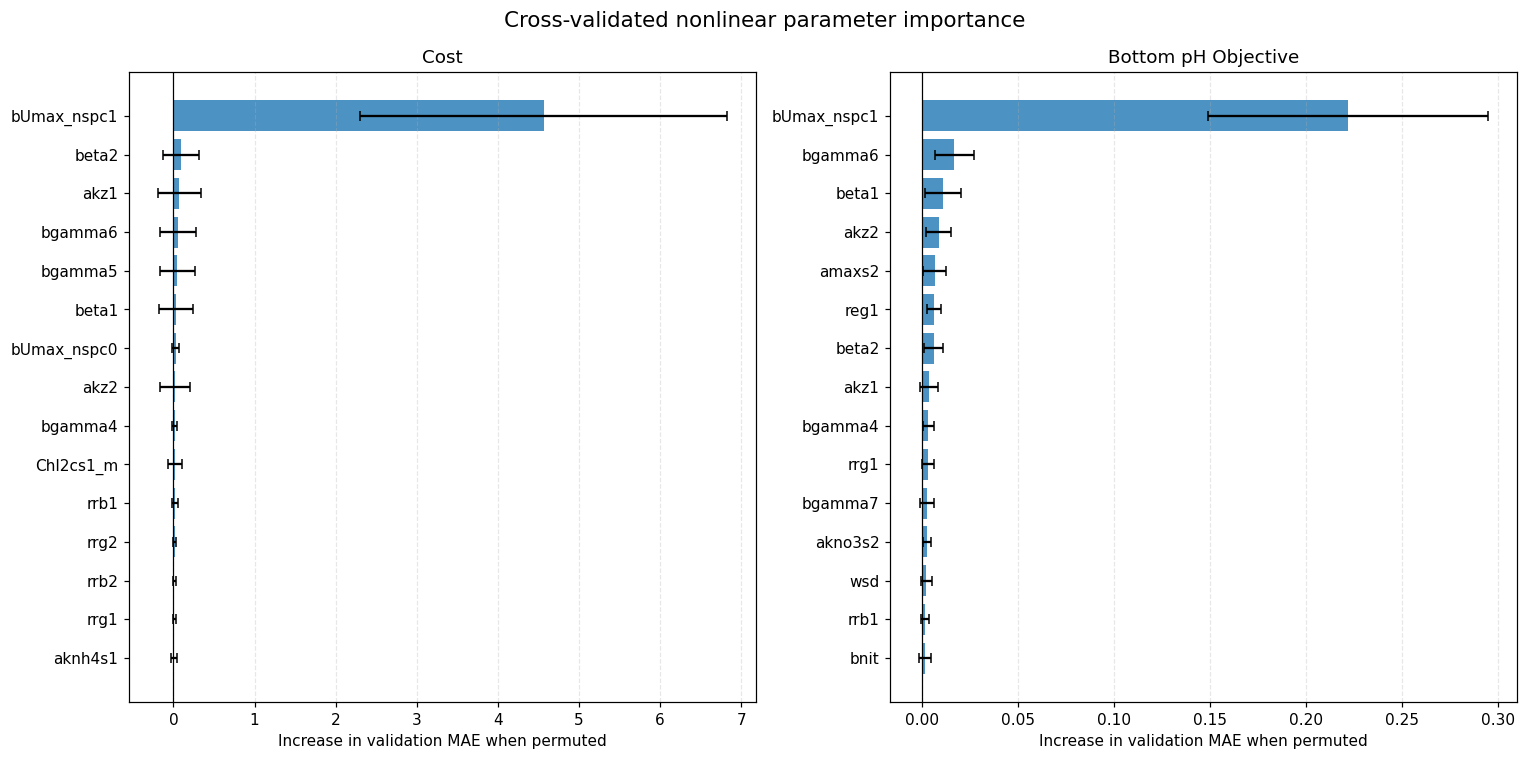

In [98]:
# squeeze=False keeps axes two-dimensional even when only one target is configured.
fig, axes = plt.subplots(1, len(ANALYSIS_TARGETS), figsize=(7 * len(ANALYSIS_TARGETS), 7), squeeze=False)
for ax, target in zip(axes.ravel(), ANALYSIS_TARGETS):
    # Reverse the top-ranked rows so the largest horizontal bar appears at the top.
    plot_data = (
        DF_permutation_importance.loc[DF_permutation_importance["Target"].eq(target)]
        .nsmallest(TOP_IMPORTANCES, "Rank").sort_values("Mean_Importance")
    )
    ax.barh(plot_data["Parameter"], plot_data["Mean_Importance"],
            xerr=plot_data["SD_Importance"], color="tab:blue", alpha=0.8, capsize=3)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set(xlabel="Increase in validation MAE when permuted", title=target)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
fig.suptitle("Cross-validated nonlinear parameter importance", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Nonlinear response and ICE plots

The gray points are actual runs. Each faint blue ICE line asks the fitted surrogate: “for this archived parameter combination, what would the prediction be if only the focus parameter changed?” The red line averages those conditional predictions.

Use the red curve to look for broad monotonic trends, thresholds, plateaus, or interior minima. Diverging blue lines indicate interactions: the estimated effect depends on other parameter values. The rug marks sampled values; curves are least trustworthy where sampling is sparse. Random forests do not extrapolate reliably beyond the tested range, and substituted parameter combinations may be physically implausible when parameters co-vary.

In [22]:
def plot_nonlinear_response(df, response_parameter, targets, parameter_columns, model,
                            show_ice=True, max_grid_points=50, max_ice_curves=100, figsize=None):
    # Plot surrogate-model average responses and individual conditional expectations.
    targets = [targets] if isinstance(targets, str) else list(targets)
    fig, axes = plt.subplots(1, len(targets), figsize=figsize or (7 * len(targets), 5), squeeze=False)
    results = {}

    for ax, target in zip(axes.ravel(), targets):
        parameters = parameter_columns.get(target, [])
        if response_parameter not in parameters:
            raise ValueError(f"{response_parameter!r} is not an eligible parameter for {target!r}.")
        # Fit each target on its own complete parameter/target rows.
        model_data = df[parameters + [target]].apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
        X, y = model_data[parameters], model_data[target]
        unique = np.sort(X[response_parameter].unique())
        if len(unique) < 2:
            raise ValueError(f"{response_parameter!r} has fewer than two values for {target!r}.")
        # Use observed settings when few exist; otherwise use quantiles to avoid an oversized grid.
        grid = unique if len(unique) <= max_grid_points else np.unique(
            X[response_parameter].quantile(np.linspace(0, 1, max_grid_points)).to_numpy()
        )
        # Clone prevents this fit from changing the reusable model template.
        fitted = clone(model).fit(X, y)
        # ICE has one row per archived run and one column per tested grid value.
        ice = np.empty((len(X), len(grid)))
        for grid_index, value in enumerate(grid):
            # Hold every other parameter fixed and replace only the focus parameter.
            modified = X.copy()
            modified[response_parameter] = value
            ice[:, grid_index] = fitted.predict(modified)
        # Averaging ICE rows gives the overall partial-dependence-style response.
        average = ice.mean(axis=0)
        results[target] = pd.DataFrame({
            response_parameter: grid, "Average Prediction": average,
            "Minimum ICE Prediction": ice.min(axis=0), "Maximum ICE Prediction": ice.max(axis=0),
        })

        # Limit visible ICE curves for readability when the archive becomes large.
        if show_ice:
            indices = np.linspace(0, len(X) - 1, min(len(X), max_ice_curves), dtype=int)
            for index in indices:
                ax.plot(grid, ice[index], color="tab:blue", linewidth=0.7, alpha=0.10, zorder=1)
            ax.plot([], [], color="tab:blue", alpha=0.5, label="Conditional responses")
        ax.scatter(X[response_parameter], y, color="gray", edgecolor="white", linewidth=0.4,
                   alpha=0.65, s=40, label="Model runs", zorder=3)
        ax.plot(grid, average, color="crimson", linewidth=2.5, marker="o", markersize=3,
                label="Average surrogate response", zorder=4)
        # The short vertical marks form a rug showing where parameter values were sampled.
        ymin, ymax = ax.get_ylim()
        ax.vlines(X[response_parameter], ymin, ymin + 0.025 * (ymax - ymin),
                  color="black", alpha=0.35, linewidth=1, zorder=2)
        ax.set_ylim(ymin, ymax)
        ax.set(xlabel=response_parameter, ylabel=target, title=f"{target} response")
        ax.grid(linestyle="--", alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f"Nonlinear and conditional responses to {response_parameter}", fontsize=14)
    plt.tight_layout()
    plt.show()
    return fig, results

Focus parameter: aksio4s2


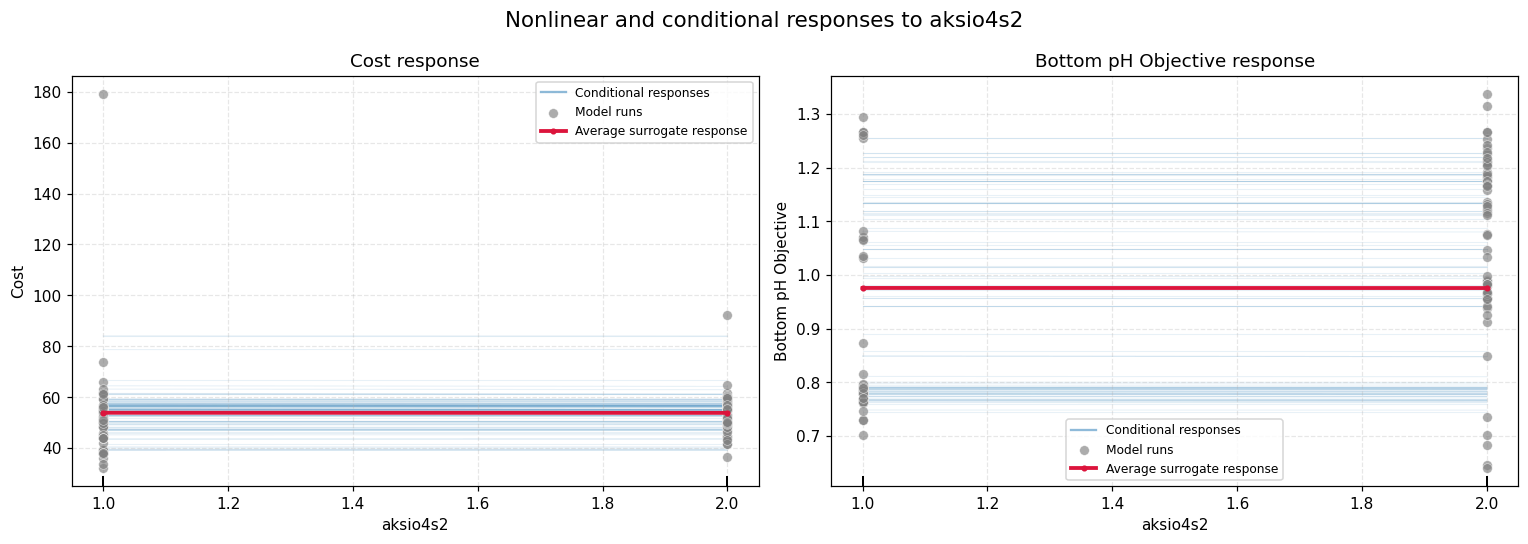

In [23]:
# Fall back to the highest mean importance for the primary target.
if FOCUS_PARAMETER is None:
    focus_parameter = (
        DF_permutation_importance.loc[DF_permutation_importance["Target"].eq(PRIMARY_TARGET)]
        .sort_values("Mean_Importance", ascending=False).iloc[0]["Parameter"]
    )
else:
    focus_parameter = FOCUS_PARAMETER

# Plot only targets whose fitted model actually includes the focus parameter.
eligible_response_targets = [
    target for target in ANALYSIS_TARGETS
    if focus_parameter in importance_parameter_cols[target]
]
print(f"Focus parameter: {focus_parameter}")
response_figure, response_results = plot_nonlinear_response(
    DF_runs, focus_parameter, eligible_response_targets,
    importance_parameter_cols, importance_model,
)

## 8. Parameter confounding and co-variation

This matrix uses Spearman rank correlation, which detects monotonic co-variation without assuming a linear relationship. Red means two parameters tend to increase together; blue means one tends to decrease as the other increases. Values near ±1 indicate strong rank association.

Strong correlations can arise from the optimizer’s search history, linked parameter settings, or a ridge of similarly good solutions. They warn that single-parameter importance and ICE curves may partly represent joint variation. Correlation alone does not identify which parameter drives model skill or biological behavior.

In [101]:
# Take the union of each target's leading parameters so neither target dominates the matrix.
top_parameter_sets = []
for target in ANALYSIS_TARGETS:
    top_parameter_sets.extend(
        DF_permutation_importance.loc[DF_permutation_importance["Target"].eq(target)]
        .nlargest(TOP_CORRELATION_PARAMETERS, "Mean_Importance")["Parameter"].tolist()
    )
# Dictionary insertion order removes duplicates while preserving importance-list order.
top_importance_parameters = list(dict.fromkeys(top_parameter_sets))
print(f"Parameters included ({len(top_importance_parameters)}):", top_importance_parameters)

Parameters included (13): ['bUmax_nspc1', 'beta2', 'akz1', 'bgamma6', 'bgamma5', 'beta1', 'bUmax_nspc0', 'akz2', 'bgamma4', 'Chl2cs1_m', 'amaxs2', 'reg1', 'rrg1']


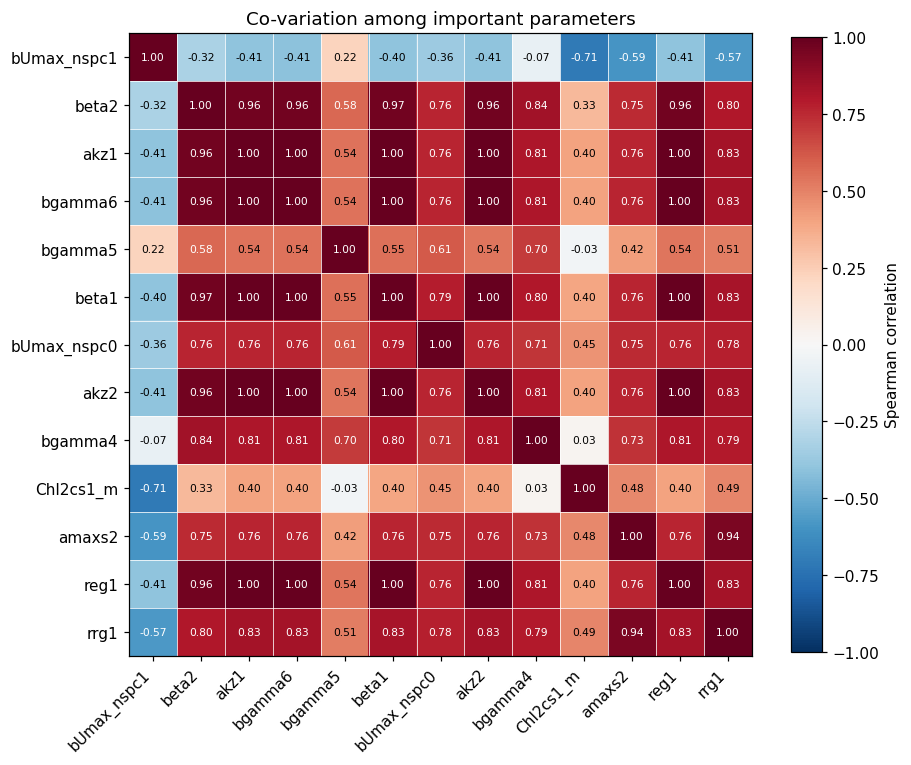

In [102]:
def plot_correlation_heatmap(df, columns, method="spearman", title="Parameter correlation matrix",
                             annotate=True, decimals=2, cmap="RdBu_r", figsize=None):
    missing = [column for column in columns if column not in df.columns]
    if missing: raise ValueError(f"Columns not found: {missing}")
    if len(columns) < 2: raise ValueError("At least two columns are required.")
    # pandas computes each correlation from rows where that pair is jointly available.
    correlation = df[columns].apply(pd.to_numeric, errors="coerce").corr(method=method)
    values, labels = correlation.to_numpy(), correlation.columns.tolist()
    size = len(labels)
    fig, ax = plt.subplots(figsize=figsize or (max(8, 0.65 * size), max(7, 0.60 * size)))
    # Fix the color scale at -1 to 1 so colors remain comparable across archives.
    image = ax.imshow(values, cmap=cmap, vmin=-1, vmax=1, aspect="equal")
    ticks = np.arange(size)
    ax.set_xticks(ticks, labels, rotation=45, ha="right")
    ax.set_yticks(ticks, labels)
    # Switch to white text on dark cells to keep values legible.
    if annotate:
        for row in range(size):
            for column in range(size):
                value = values[row, column]
                label = "NA" if np.isnan(value) else f"{value:.{decimals}f}"
                ax.text(column, row, label, ha="center", va="center", fontsize=7,
                        color="white" if not np.isnan(value) and abs(value) >= 0.55 else "black")
    boundaries = np.arange(-0.5, size, 1)
    ax.set_xticks(boundaries, minor=True)
    ax.set_yticks(boundaries, minor=True)
    ax.grid(which="minor", color="white", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    fig.colorbar(image, ax=ax, shrink=0.8, label=f"{method.capitalize()} correlation")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return correlation, fig, ax


DF_parameter_correlations, correlation_figure, correlation_axis = plot_correlation_heatmap(
    DF_runs, top_importance_parameters, method="spearman",
    title="Co-variation among important parameters",
)

In [103]:
# Visit only the upper triangle so each pair appears once and self-correlations are omitted.
pairs = []
for index, parameter_1 in enumerate(top_importance_parameters):
    for parameter_2 in top_importance_parameters[index + 1:]:
        correlation = DF_parameter_correlations.loc[parameter_1, parameter_2]
        pairs.append({
            "Parameter 1": parameter_1, "Parameter 2": parameter_2,
            "Spearman Correlation": correlation, "Absolute Correlation": abs(correlation),
        })
DF_correlation_pairs = pd.DataFrame(pairs).sort_values("Absolute Correlation", ascending=False).reset_index(drop=True)
print(f"Pairs with |Spearman correlation| >= {STRONG_CORRELATION:.2f}")
display(DF_correlation_pairs.loc[DF_correlation_pairs["Absolute Correlation"].ge(STRONG_CORRELATION)])

# Also provide a one-parameter view, sorted by correlation magnitude.
if focus_parameter in DF_parameter_correlations.columns:
    focus_correlations = (
        DF_parameter_correlations[focus_parameter].drop(focus_parameter)
        .sort_values(key=lambda values: values.abs(), ascending=False)
        .rename("Spearman Correlation").to_frame()
    )
    focus_correlations["Absolute Correlation"] = focus_correlations["Spearman Correlation"].abs()
    print(f"Correlations with focus parameter {focus_parameter!r}")
    display(focus_correlations)

Pairs with |Spearman correlation| >= 0.70


,Parameter 1,Parameter 2,Spearman Correlation,Absolute Correlation
0,akz1,bgamma6,0.999193,0.999193
1,akz2,reg1,0.998870,0.998870
2,akz1,akz2,0.998749,0.998749
3,bgamma6,reg1,0.998547,0.998547
4,bgamma6,akz2,0.998345,0.998345
5,akz1,reg1,0.997821,0.997821
6,bgamma6,beta1,0.996274,0.996274
7,beta1,reg1,0.996033,0.996033
8,beta1,akz2,0.995430,0.995430
9,akz1,beta1,0.995390,0.995390


Correlations with focus parameter 'bUmax_nspc1'


,Spearman Correlation,Absolute Correlation
Chl2cs1_m,-0.709094,0.709094
amaxs2,-0.586859,0.586859
rrg1,-0.570872,0.570872
bgamma6,-0.407200,0.407200
akz2,-0.406110,0.406110
akz1,-0.405688,0.405688
reg1,-0.405161,0.405161
beta1,-0.401429,0.401429
bUmax_nspc0,-0.359766,0.359766
beta2,-0.317804,0.317804


## 9. Interpretation checklist

Before selecting new parameter values or narrowing bounds, ask:

1. Did the best-so-far curve continue improving near the end, or has it been flat across substantial exploration?
2. Does the nonlinear model beat the mean baseline on held-out data with an acceptable train/test gap?
3. Is a parameter important consistently (`Positive_Fraction` near 1), or is its mean driven by unstable folds?
4. Does the elite range contain several unique sampled values, and does it touch a search boundary?
5. Do ICE lines agree on response direction, and is the relevant x-axis region well sampled?
6. Is the parameter strongly correlated with another important parameter?

The strongest evidence for follow-up is agreement across diagnostics: a stable cross-validated importance, a well-sampled response pattern, concentration among elite runs, and limited confounding. Confirm any proposed setting with new mechanistic model runs.